## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [23]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

In [24]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_ID = 'EL52'

In [25]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022_new.csv", encoding = enc)
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.168909,2.702302,4.435606,2.617253,1043.454545,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,1989.946627,1.989528,0,66.416132,2.247180,156.610698,0.0,1.011277,21798.191901,3076.253101,22,298.302356,1731.204958,196.239091,0.000000,270.507602,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.00000,40.400688,31,36,30,12,12,1,6,7,2,-0.015091,12.092545,81.134845,0,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,11806.0,44835.0,13866.0,70507.0,11360.0,44584.0,16384.0,72328.0,2016.25,NaN,NaN
1,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,1,2010,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,7.923406,1.710122,4.816764,1.364895,740.125984,8521.365773,2204.562938,6.102362,170.376578,294.050327,182.310346,0.006741,5.908999,0.000000,17.827161,0,56.759352,0.011757,171.076734,0.0,1.000000,23612.311438,3824.269329,21,259.278723,743.564282,204.563920,0.856134,90.059826,5609.020284,824.307566,4.668086,44.086739,209.575010,6.368472,0.07597,10.388872,31,30,30,10,10,1,6,6,2,-2.877717,13.860079,42.311748,0,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,87330.0,375115.0,82051.0,544496.0,84172.0,402246.0,107376.0,593794.0,19627.51,NaN,NaN
2,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,1,2010,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,7.190461,0.340620,3.765541,1.715277,631.285714,10953.820049,1566.657477,6.461538,153.325412,268.365723,177.491290,0.028224,21.371767,0.000000,5.978432,0,66.960739,27.476440,145.370004,0.0,1.000000,18812.025826,3690.955644,16,263.321585,728.984349,195.905926,0.856134,132.827131,4323.473197,1069.109617,4.638744,47.658551,207.195696,11.096824,0.15371,39.002021,31,36,30,12,12,3,5,8,2,-4.895934,12.183407,53.173589,0,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,5963.0,24603.0,9769.0,40335.0,5680.0,23436.0,11889.0,41005.0,1124.52,NaN,NaN
3,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.414831,0.975051,3.694941,2.628748,869.318182,17893.740654,1234.209371,10.625000,142.505681,490.492098,175.009793,0.000000,16.377415,1316.915891,27.811651,1,54.056037,2.247180,120.888527,0.0,1.000000,29517.602842,2981.658448,34,285.203353,1312.399181,198.228534,0.000000,335.786979,8324.26

<AxesSubplot:>

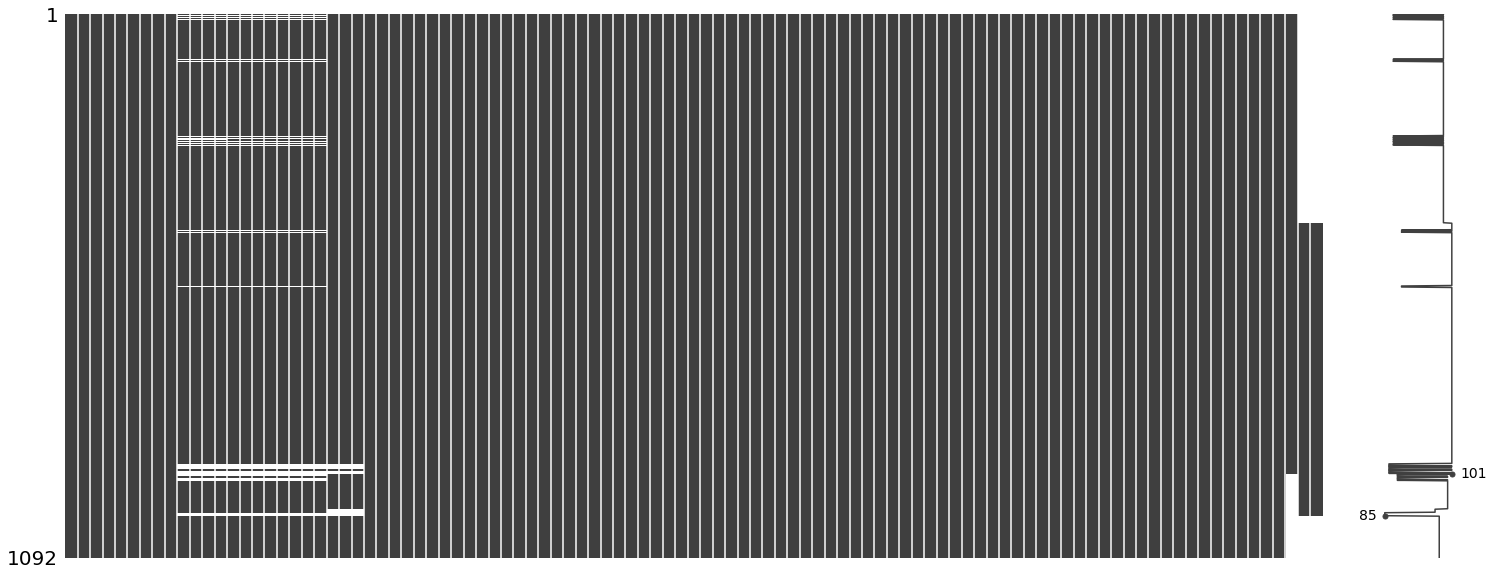

In [26]:
missingno.matrix(dataset_monthly)

In [27]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
0,ndvi,5.2198
1,ndmi,5.2198
2,ndwi,5.2198
3,ndbi,5.2198
4,ndvi_mean,5.1282
5,ndmi_mean,5.1282
6,ndwi_mean,5.1282
7,ndbi_mean,5.1282
8,ndvi_std,5.1282
9,ndmi_std,5.1282


In [28]:
years = dataset_monthly.year.unique()
nuts3_units = dataset_monthly.NUTS3_ID.unique()

In [29]:
data_p1 = []
data_p2 = []

for year in years[1:]:
    for region in nuts3_units:
        df_regional = dataset_monthly.loc[(dataset_monthly['NUTS3_ID'] == region)].copy()
        df_regional.reset_index(drop = True, inplace = True)

        df_period_1 = df_regional.loc[((df_regional['year'] == year-1) & (df_regional['month'] >= 11)) | ((df_regional['year'] == year) & (df_regional['month'] == 1))].copy()
        df_period_2 = df_regional.loc[((df_regional['year'] == year-1) & (df_regional['month'] >= 11)) | ((df_regional['year'] == year) & (df_regional['month'] <= 4))].copy()
        #df_period_2 = df_regional.loc[(df_regional['year'] == 2011) & (df_regional['month'] >= 2) & (df_regional['month'] <= 4)].copy()
        df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
        df_curr_year = df_regional.loc[(df_regional['year'] == year)].copy()

        x = df_curr_year['x'].mean()
        y = df_curr_year['y'].mean()

        ndvi_p1 = df_period_1['ndvi'].mean()
        ndwi_p1 = df_period_1['ndwi'].mean()
        ndmi_p1 = df_period_1['ndmi'].mean()
        ndbi_p1 = df_period_1['ndbi'].mean()

        ndvi_p2 = df_period_2['ndvi'].mean()
        ndwi_p2 = df_period_2['ndwi'].mean()
        ndmi_p2 = df_period_2['ndmi'].mean()
        ndbi_p2 = df_period_2['ndbi'].mean()
        #------------------------------------------------------
        lst_mean_p1 = df_period_1['lst'].mean()
        lst_day_mean_p1 = df_period_1['lst_day'].mean()
        lst_night_mean_p1 = df_period_1['lst_night'].mean()
        lst_min_p1 = df_period_1['monthly_lst_min'].min()
        lst_max_p1 = df_period_1['monthly_lst_min'].max()

        lst_mean_p2 = df_period_2['lst'].mean()
        lst_day_mean_p2 = df_period_2['lst_day'].mean()
        lst_night_mean_p2 = df_period_2['lst_night'].mean()
        lst_min_p2 = df_period_2['monthly_lst_min'].min()
        lst_max_p2 = df_period_2['monthly_lst_min'].max()
        #-------------------------------------------------------
        prec_mean_p1 = df_period_1['rainfall'].mean()
        prec_acc_p1 = df_period_1['monthly_acc_prec'].sum()

        prec_mean_p2 = df_period_2['rainfall'].mean()
        prec_acc_p2 = df_period_2['monthly_acc_prec'].sum()
        #-------------------------------------------------------
        mosq_mean_p1 = df_period_1['mosq_pred'].mean()
        mosq_sum_p1 = df_period_1['mosq_pred'].sum()

        mosq_mean_p2 = df_period_2['mosq_pred'].mean()
        mosq_sum_p2 = df_period_2['mosq_pred'].sum()
        #--------------------------------------------------------
        bio1 = df_prev_year.iloc[0]['bio1']
        bio2 = df_prev_year.iloc[0]['bio2']
        bio3 = df_prev_year.iloc[0]['bio3']
        bio4 = df_prev_year.iloc[0]['bio4']
        bio5 = df_prev_year.iloc[0]['bio5']
        bio6 = df_prev_year.iloc[0]['bio6']
        bio7 = df_prev_year.iloc[0]['bio7']
        bio8 = df_prev_year.iloc[0]['bio8']
        bio9 = df_prev_year.iloc[0]['bio9']
        bio10 = df_prev_year.iloc[0]['bio10']
        bio11 = df_prev_year.iloc[0]['bio11']
        bio12 = df_prev_year.iloc[0]['bio12']
        bio13 = df_prev_year.iloc[0]['bio13']
        bio14 = df_prev_year.iloc[0]['bio14']
        bio15 = df_prev_year.iloc[0]['bio15']
        bio16 = df_prev_year.iloc[0]['bio16']
        bio17 = df_prev_year.iloc[0]['bio17']
        bio18 = df_prev_year.iloc[0]['bio18']
        bio19 = df_prev_year.iloc[0]['bio19']
        #--------------------------------------------------------
        lc_prop1 = df_prev_year.iloc[0]['lc_prop1']
        lc_prop2 = df_prev_year.iloc[0]['lc_prop2']
        lc_prop3 = df_prev_year.iloc[0]['lc_prop3']
        lc_type1 = df_prev_year.iloc[0]['lc_type1']
        lc_type2 = df_prev_year.iloc[0]['lc_type2']
        lc_type3 = df_prev_year.iloc[0]['lc_type3']
        lc_type4 = df_prev_year.iloc[0]['lc_type4']
        lc_type5 = df_prev_year.iloc[0]['lc_type5']
        #--------------------------------------------------------
        distance_to_coast = df_prev_year.iloc[0]['distance_to_coast']
        distance_to_river = df_prev_year.iloc[0]['distance_to_river']
        slope_mean_1km = df_prev_year.iloc[0]['slope_mean_1km']
        aspect_mean_200m = df_prev_year.iloc[0]['aspect_mean_200m']
        elevation_mean_1km = df_prev_year.iloc[0]['elevation_mean_1km']
        hillshade_mean_1km = df_prev_year.iloc[0]['hillshade_mean_1km']
        fs_area_1km = df_prev_year.iloc[0]['fs_area_1km']
        flow_accu_200m = df_prev_year.iloc[0]['flow_accu_200m']

        distance_to_coast_std = df_prev_year.iloc[0]['distance_to_coast_std']
        distance_to_river_std = df_prev_year.iloc[0]['distance_to_river_std']
        slope_mean_1km_std = df_prev_year.iloc[0]['slope_mean_1km_std']
        aspect_mean_200m_std = df_prev_year.iloc[0]['aspect_mean_200m_std']
        elevation_mean_1km_std = df_prev_year.iloc[0]['elevation_mean_1km_std']
        hillshade_mean_1km_std = df_prev_year.iloc[0]['hillshade_mean_1km_std']
        fs_area_1km_std = df_prev_year.iloc[0]['fs_area_1km_std']
        flow_accu_200m_std = df_prev_year.iloc[0]['flow_accu_200m_std']
        #--------------------------------------------------------
        males_lt15 = df_prev_year.iloc[0]['M_Y_LT15']
        males_15t64 = df_prev_year.iloc[0]['M_Y15-64']
        males_gt65 = df_prev_year.iloc[0]['M_Y_GE65']
        males_total = df_prev_year.iloc[0]['M_TOTAL']

        females_lt15 = df_prev_year.iloc[0]['F_Y_LT15']
        females_15t64 = df_prev_year.iloc[0]['F_Y15-64']
        females_gt65 = df_prev_year.iloc[0]['F_Y_GE65']
        females_total = df_prev_year.iloc[0]['F_TOTAL']

        mio_eur = df_prev_year.iloc[0]['MIO_EUR']
        l_total = df_prev_year.iloc[0]['L_TOTAL']
        unl_total = df_prev_year.iloc[0]['UNL_TOTAL']
        #--------------------------------------------------------
        cases_total = df_curr_year['cases'].sum()
        cases_arr = df_curr_year.loc[(df_curr_year['month'] >= 5) & (df_curr_year['month'] <= 10)]['cases'].to_list()

        data_p1.append({'NUTS3_ID': region, 
                     'year': year, 
                     'x' : x,
                     'y': y,
                     'ndvi_p1': ndvi_p1,
                     'ndwi_p1': ndwi_p1,
                     'ndmi_p1': ndmi_p1,
                     'ndbi_p1': ndbi_p1,
                     'lst_mean_p1': lst_mean_p1,
                     'lst_day_mean_p1': lst_day_mean_p1,
                     'lst_night_mean_p1': lst_night_mean_p1,
                     'lst_min_p1': lst_min_p1,
                     'lst_max_p1': lst_max_p1,
                     'prec_mean_p1': prec_mean_p1,
                     'prec_acc_p1': prec_acc_p1,
                     'mosq_mean_p1': mosq_mean_p1,
                     'mosq_sum_p1': mosq_sum_p1,
                     'bio1': bio1,
                     'bio2': bio2,
                     'bio3': bio3,
                     'bio4': bio4,
                     'bio5': bio5,
                     'bio6': bio6,
                     'bio7': bio7,
                     'bio8': bio8,
                     'bio9': bio9,
                     'bio10': bio10,
                     'bio11': bio11,
                     'bio12': bio12,
                     'bio13': bio13,
                     'bio14': bio14,
                     'bio15': bio15,
                     'bio16': bio16,
                     'bio17': bio17,
                     'bio18': bio18,
                     'bio19': bio19,
                     'lc_prop1': lc_prop1,
                     'lc_prop2': lc_prop2,
                     'lc_prop3': lc_prop3,
                     'lc_type1': lc_type1,
                     'lc_type2': lc_type2,
                     'lc_type3': lc_type3,
                     'lc_type4': lc_type4,
                     'lc_type5': lc_type5,
                     'distance_to_coast': distance_to_coast,
                     'distance_to_river': distance_to_river,
                     'slope_mean_1km': slope_mean_1km,
                     'aspect_mean_200m': aspect_mean_200m,
                     'elevation_mean_1km': elevation_mean_1km,
                     'hillshade_mean_1km': hillshade_mean_1km,
                     'fs_area_1km': fs_area_1km,
                     'flow_accu_200m': flow_accu_200m,
                     'distance_to_coast_std': distance_to_coast_std,
                     'distance_to_river_std': distance_to_river_std,
                     'slope_mean_1km_std': slope_mean_1km_std,
                     'aspect_mean_200m_std': aspect_mean_200m_std,
                     'elevation_mean_1km_std': elevation_mean_1km_std,
                     'hillshade_mean_1km_std': hillshade_mean_1km_std,
                     'fs_area_1km_std': fs_area_1km_std,
                     'flow_accu_200m_std': flow_accu_200m_std,
                     'males_lt15': males_lt15,
                     'males_15t64': males_15t64,
                     'males_gt65': males_gt65,
                     'males_total': males_total,
                     'females_lt15': females_lt15,
                     'females_15t64': females_15t64,
                     'females_gt65': females_gt65,
                     'females_total': females_total,
                     'mio_eur': mio_eur,
                     'l_total': l_total,
                     'unl_total': unl_total,
                     'mio_eur': mio_eur,
                     'cases_total': cases_total,
                     'cases_arr': cases_arr,
                     })

        data_p2.append({'NUTS3_ID': region, 
                     'year': year,
                     'x' : x,
                     'y': y, 
                     'ndvi_p1': ndvi_p2,
                     'ndwi_p1': ndwi_p2,
                     'ndmi_p1': ndmi_p2,
                     'ndbi_p1': ndbi_p2,
                     'lst_mean_p1': lst_mean_p2,
                     'lst_day_mean_p1': lst_day_mean_p2,
                     'lst_night_mean_p1': lst_night_mean_p2,
                     'lst_min_p1': lst_min_p2,
                     'lst_max_p1': lst_max_p2,
                     'prec_mean_p1': prec_mean_p2,
                     'prec_acc_p1': prec_acc_p2,
                     'mosq_mean_p1': mosq_mean_p2,
                     'mosq_sum_p1': mosq_sum_p2,
                     'bio1': bio1,
                     'bio2': bio2,
                     'bio3': bio3,
                     'bio4': bio4,
                     'bio5': bio5,
                     'bio6': bio6,
                     'bio7': bio7,
                     'bio8': bio8,
                     'bio9': bio9,
                     'bio10': bio10,
                     'bio11': bio11,
                     'bio12': bio12,
                     'bio13': bio13,
                     'bio14': bio14,
                     'bio15': bio15,
                     'bio16': bio16,
                     'bio17': bio17,
                     'bio18': bio18,
                     'bio19': bio19,
                     'lc_prop1': lc_prop1,
                     'lc_prop2': lc_prop2,
                     'lc_prop3': lc_prop3,
                     'lc_type1': lc_type1,
                     'lc_type2': lc_type2,
                     'lc_type3': lc_type3,
                     'lc_type4': lc_type4,
                     'lc_type5': lc_type5,
                     'distance_to_coast': distance_to_coast,
                     'distance_to_river': distance_to_river,
                     'slope_mean_1km': slope_mean_1km,
                     'aspect_mean_200m': aspect_mean_200m,
                     'elevation_mean_1km': elevation_mean_1km,
                     'hillshade_mean_1km': hillshade_mean_1km,
                     'fs_area_1km': fs_area_1km,
                     'flow_accu_200m': flow_accu_200m,
                     'distance_to_coast_std': distance_to_coast_std,
                     'distance_to_river_std': distance_to_river_std,
                     'slope_mean_1km_std': slope_mean_1km_std,
                     'aspect_mean_200m_std': aspect_mean_200m_std,
                     'elevation_mean_1km_std': elevation_mean_1km_std,
                     'hillshade_mean_1km_std': hillshade_mean_1km_std,
                     'fs_area_1km_std': fs_area_1km_std,
                     'flow_accu_200m_std': flow_accu_200m_std,
                     'males_lt15': males_lt15,
                     'males_15t64': males_15t64,
                     'males_gt65': males_gt65,
                     'males_total': males_total,
                     'females_lt15': females_lt15,
                     'females_15t64': females_15t64,
                     'females_gt65': females_gt65,
                     'females_total': females_total,
                     'mio_eur': mio_eur,
                     'l_total': l_total,
                     'unl_total': unl_total,
                     'mio_eur': mio_eur,
                     'cases_total': cases_total,
                     'cases_arr': cases_arr,
                     })
        
p1_df = pd.DataFrame(data_p1)       
p2_df = pd.DataFrame(data_p2) 

In [30]:
p1_df

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL521,2011,22.215876,40.552658,0.252698,0.164174,0.372403,-0.372403,6.208697,9.993104,2.424290,-5.821636,3.715091,3.286000,301.706854,433.757576,1301.272727,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,31,36,30,12,12,1,6,7,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.00000,40.400688,11806.0,44835.0,13866.0,70507.0,11360.0,44584.0,16384.0,72328.0,2016.25,NaN,NaN,6,"[0, 0, 2, 2, 2, 0]"
1,EL522,2011,23.139532,40.695359,0.265538,0.022865,0.253202,-0.253202,7.444165,11.375891,3.512438,-4.746063,5.242598,2.104167,193.713711,278.692913,836.078740,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,31,30,30,10,10,1,6,6,8521.365773,2204.562938,6.102362,170.376578,294.050327,182.310346,0.006741,5.908999,5609.020284,824.307566,4.668086,44.086739,209.575010,6.368472,0.07597,10.388872,87330.0,375115.0,82051.0,544496.0,84172.0,402246.0,107376.0,593794.0,19627.51,NaN,NaN,10,"[0, 0, 3, 4, 3, 0]"
2,EL523,2011,22.758634,41.016242,0.193572,0.101583,0.277345,-0.277345,6.740102,10.879505,2.600698,-5.194396,5.133956,2.543045,233.660050,279.853480,839.560440,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,31,36,30,12,12,3,5,8,10953.820049,1566.657477,6.461538,153.325412,268.365723,177.491290,0.028224,21.371767,4323.473197,1069.109617,4.638744,47.658551,207.195696,11.096824,0.15371,39.002021,5963.0,24603.0,9769.0,40335.0,5680.0,23436.0,11889.0,41005.0,1124.52,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
3,EL524,2011,22.109199,40.888821,0.252725,0.133880,0.354723,-0.354723,6.226510,10.217141,2.235878,-5.870000,4.123182,3.739724,343.464625,308.363636,925.090909,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,31,20,30,12,9,4,4,4,17893.740654,1234.209371,10.625000,142.505681,490.492098,175.009793,0.000000,16.377415,8324.265122,733.091339,9.669614,58.636781,412.361568,15.303624,0.00000,46.596750,11159.0,44537.0,14694.0,70390.0,11052.0,43212.0,17690.0,71954.0,1938.34,NaN,NaN,8,"[0, 0, 0, 3, 5, 0]"
4,EL525,2011,22.441443,40.269748,0.243297,0.118603,0.330566,-0.330566,7.617001,11.342695,3.891308,-4.498444,5.272222,2.673776,245.693081,484.000000,1452.000000,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,31,36,30,12,12,1,6,7,11735.919071,971.980212,13.400000,134.587334,430.793162,170.687146,0.000000,21.108785,5383.969555,789.936868,8.881544,48.186142,455.707394,9.701413,0.00000,46.416540,10433.0,40170.0,12062.0,62665.0,10152.0,40273.0,14620.0,65045.0,1725.03,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [31]:
p2_df

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL521,2011,22.215876,40.552658,0.305573,0.005573,0.272847,-0.272847,8.026175,12.909024,3.143326,-5.821636,3.715091,2.918223,528.658049,1243.790909,7462.745455,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,31,36,30,12,12,1,6,7,12508.751326,1619.864045,10.909091,167.274024,471.994054,174.613165,0.000000,12.577415,6127.601421,866.789289,7.655240,68.916213,547.059733,11.787599,0.00000,40.400688,11806.0,44835.0,13866.0,70507.0,11360.0,44584.0,16384.0,72328.0,2016.25,NaN,NaN,6,"[0, 0, 2, 2, 2, 0]"
1,EL522,2011,23.139532,40.695359,0.333062,-0.128818,0.176046,-0.176046,8.841823,13.876891,3.806754,-4.746063,5.242598,2.295142,414.726211,621.607612,3729.645669,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,31,30,30,10,10,1,6,6,8521.365773,2204.562938,6.102362,170.376578,294.050327,182.310346,0.006741,5.908999,5609.020284,824.307566,4.668086,44.086739,209.575010,6.368472,0.07597,10.388872,87330.0,375115.0,82051.0,544496.0,84172.0,402246.0,107376.0,593794.0,19627.51,NaN,NaN,10,"[0, 0, 3, 4, 3, 0]"
2,EL523,2011,22.758634,41.016242,0.276666,-0.136946,0.125340,-0.125340,8.751504,14.059970,3.443038,-11.573333,5.133956,2.205747,400.370860,573.214286,3439.285714,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,31,36,30,12,12,3,5,8,10953.820049,1566.657477,6.461538,153.325412,268.365723,177.491290,0.028224,21.371767,4323.473197,1069.109617,4.638744,47.658551,207.195696,11.096824,0.15371,39.002021,5963.0,24603.0,9769.0,40335.0,5680.0,23436.0,11889.0,41005.0,1124.52,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
3,EL524,2011,22.109199,40.888821,0.314644,-0.037971,0.248726,-0.248726,8.187227,13.196271,3.178183,-5.870000,4.123182,2.888951,525.702605,950.160985,5700.965909,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,31,20,30,12,9,4,4,4,17893.740654,1234.209371,10.625000,142.505681,490.492098,175.009793,0.000000,16.377415,8324.265122,733.091339,9.669614,58.636781,412.361568,15.303624,0.00000,46.596750,11159.0,44537.0,14694.0,70390.0,11052.0,43212.0,17690.0,71954.0,1938.34,NaN,NaN,8,"[0, 0, 0, 3, 5, 0]"
4,EL525,2011,22.441443,40.269748,0.320886,-0.036387,0.253218,-0.253218,8.695749,13.148467,4.243032,-4.498444,5.272222,2.939328,529.913092,1388.522222,8331.133333,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,31,36,30,12,12,1,6,7,11735.919071,971.980212,13.400000,134.587334,430.793162,170.687146,0.000000,21.108785,5383.969555,789.936868,8.881544,48.186142,455.707394,9.701413,0.00000,46.416540,10433.0,40170.0,12062.0,62665.0,10152.0,40273.0,14620.0,65045.0,1725.03,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

<AxesSubplot:>

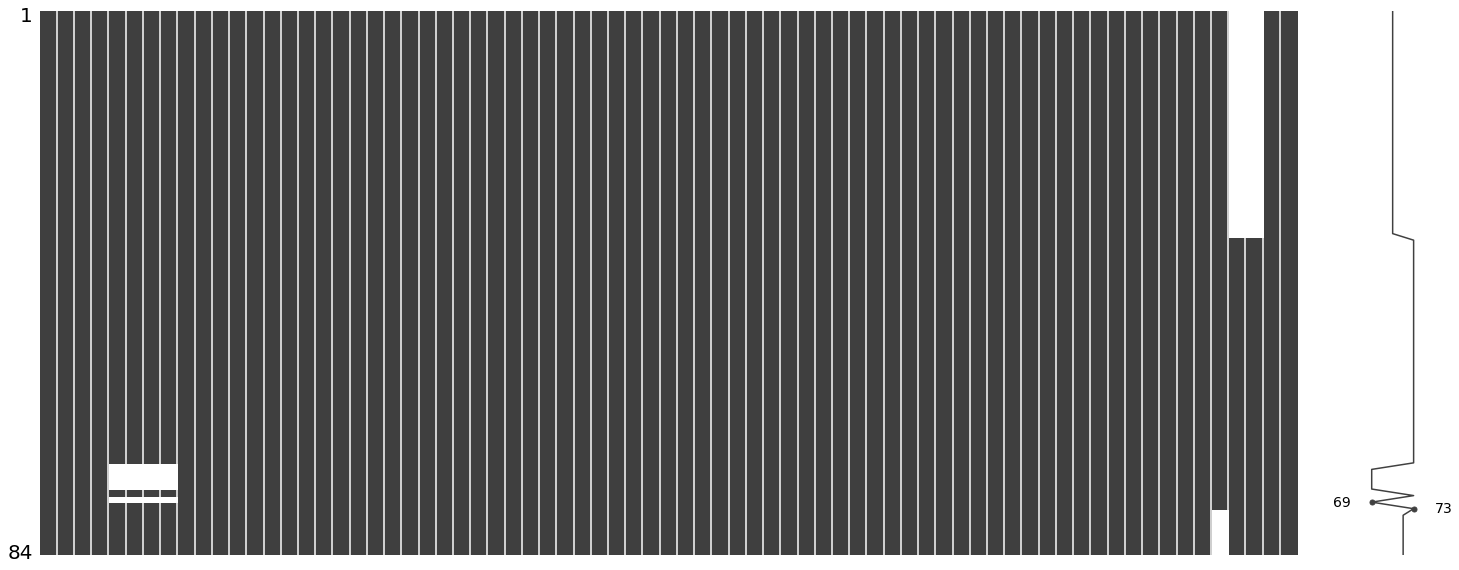

In [32]:
missingno.matrix(p1_df)

<AxesSubplot:>

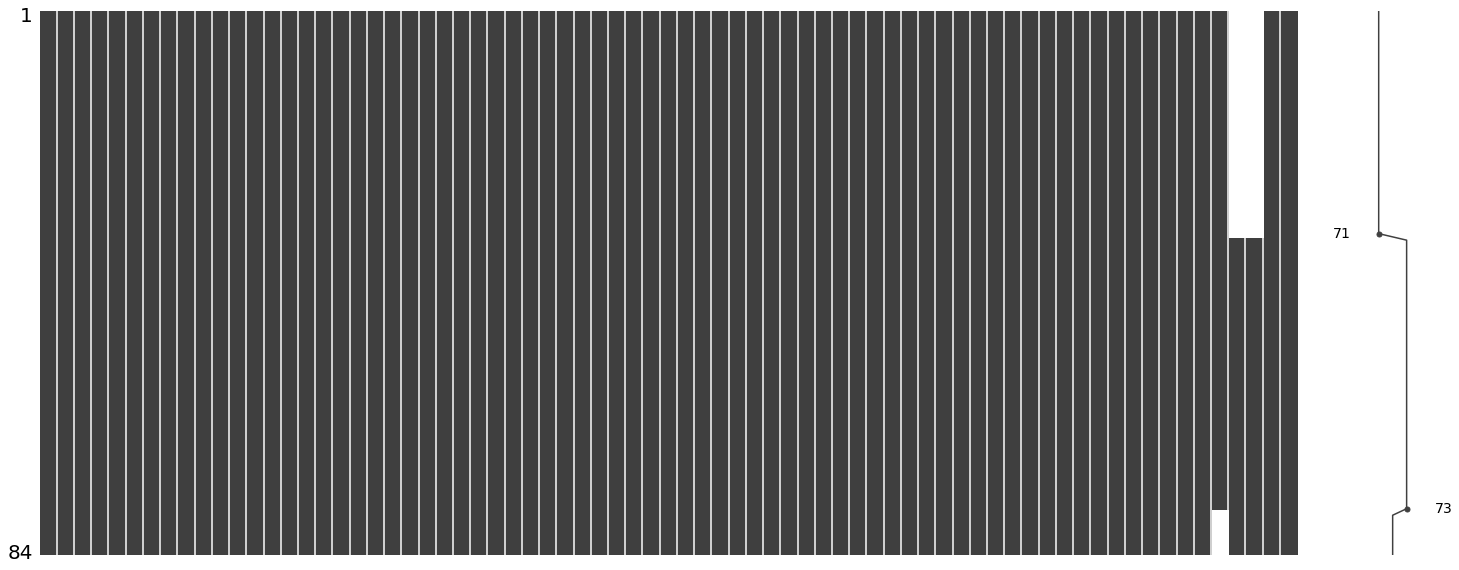

In [33]:
missingno.matrix(p2_df)

In [34]:
missing = describe_dataframe(p1_df, remove_zeros=True)
missing

,Column,Missing
0,ndvi_p1,5.9524
1,ndwi_p1,5.9524
2,ndmi_p1,5.9524
3,ndbi_p1,5.9524
4,mio_eur,8.3333
5,l_total,41.6667
6,unl_total,41.6667


In [35]:
missing = describe_dataframe(p2_df, remove_zeros=True)
missing

,Column,Missing
0,mio_eur,8.3333
1,l_total,41.6667
2,unl_total,41.6667


In [36]:
p1_df.cases_total.sum()

613

In [37]:
p2_df.cases_total.sum()

613

In [38]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'mio_eur']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['mio_eur']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

In [39]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'l_total']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['l_total']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

In [40]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'unl_total']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['unl_total']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

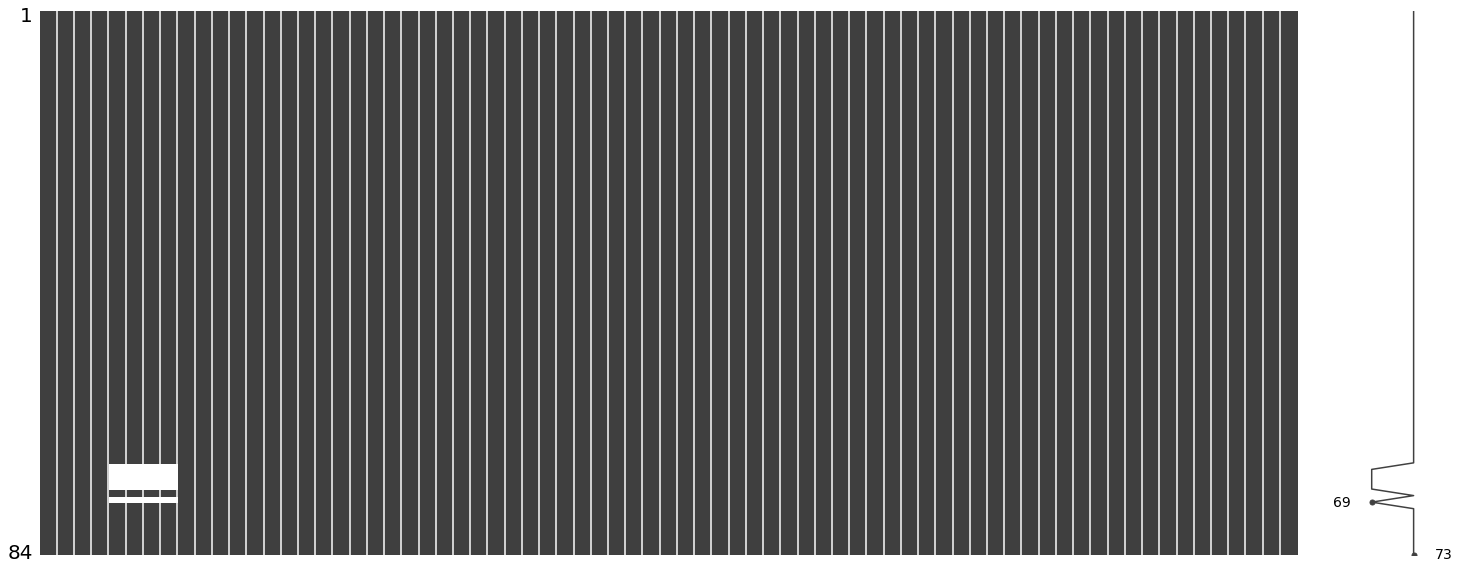

In [41]:
missingno.matrix(p1_df, label_rotation=90)

<AxesSubplot:>

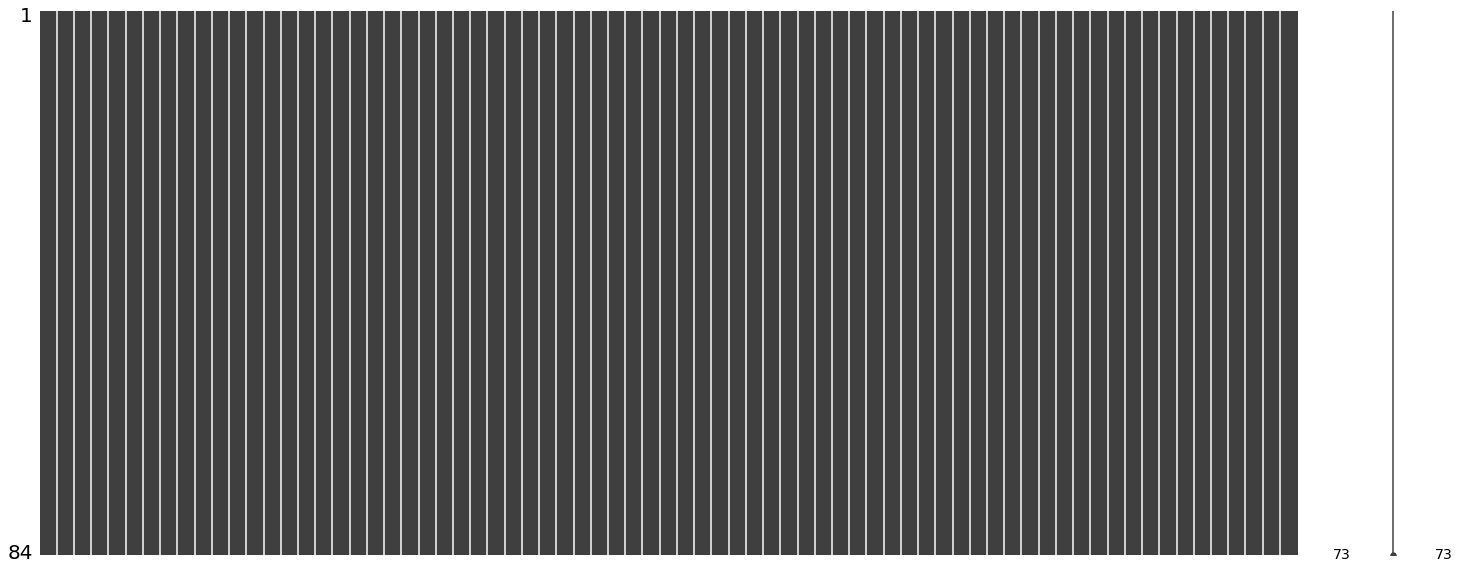

In [42]:
missingno.matrix(p2_df, label_rotation=90)

<AxesSubplot:>

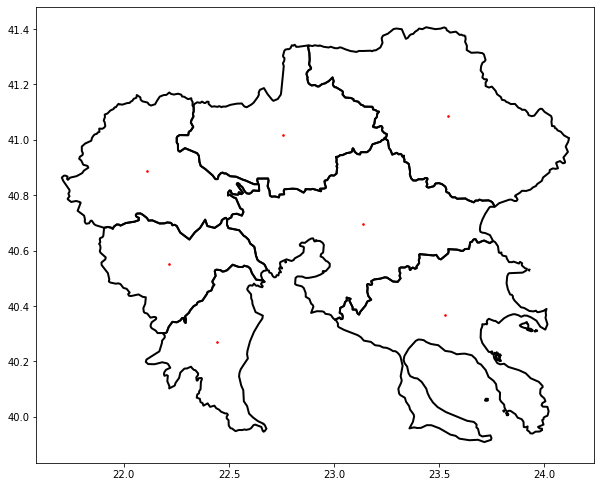

In [43]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(p1_df[['NUTS3_ID']], geometry=gpd.points_from_xy(p1_df.x, p1_df.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [44]:
p1_df.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_P1_2011_2022.csv", encoding = enc, index = False)
p1_df.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_P2_2011_2022.csv", encoding = enc, index = False)